In [1]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)
if not gpus:
    raise RuntimeError(
        "No GPU detected. Go to Runtime > Change runtime type > "
        "select T4 GPU > Save, then re-run this cell before continuing."
    )

GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

!rm -rf /content/processed

In [4]:
# Adjust this path if you uploaded processed.zip somewhere else in Drive.
!unzip -q "/content/drive/MyDrive/dental-vision/processed.zip" -d /content/

In [5]:
!ls -la /content/processed/

total 20
drwxr-xr-x 5 root root 4096 Jul 15 01:02 .
drwxr-xr-x 1 root root 4096 Jul 15 01:02 ..
drwxr-xr-x 7 root root 4096 Jul 13 10:00 test
drwxr-xr-x 7 root root 4096 Jul 13 09:59 train
drwxr-xr-x 7 root root 4096 Jul 13 09:59 valid


In [6]:
import pathlib

for split in ["train", "valid", "test"]:
    split_path = pathlib.Path("/content/processed") / split
    if not split_path.exists():
        print(f"WARNING: {split_path} does not exist -- check the unzip step above.")
        continue
    for cls in sorted(split_path.iterdir()):
        if cls.is_dir():
            n = len(list(cls.glob("*.jpg")))
            print(f"{split}/{cls.name}: {n} images")

train/Bone_Loss: 2182 images
train/Caries: 7384 images
train/Impacted_Tooth: 19775 images
train/Missing_Teeth: 2338 images
train/Periapical_Lesion: 3693 images
valid/Bone_Loss: 420 images
valid/Caries: 1624 images
valid/Impacted_Tooth: 4087 images
valid/Missing_Teeth: 613 images
valid/Periapical_Lesion: 806 images
test/Bone_Loss: 528 images
test/Caries: 1716 images
test/Impacted_Tooth: 4116 images
test/Missing_Teeth: 552 images
test/Periapical_Lesion: 792 images


## Training notebook starts here

# DentalVision - Model Training

This notebook trains an EfficientNetB0 model to classify dental diseases from cropped dental X-ray images.

In [7]:
import os
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [8]:
print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [10]:
DATASET_PATH = pathlib.Path("/content/processed")

TRAIN_PATH = DATASET_PATH / "train"
VALID_PATH = DATASET_PATH / "valid"
TEST_PATH = DATASET_PATH / "test"

MODEL_PATH = pathlib.Path("/content/drive/MyDrive/dental-vision/models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

In [11]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 10

In [12]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 35372 files belonging to 5 classes.
Found 7550 files belonging to 5 classes.
Found 7704 files belonging to 5 classes.


In [13]:
class_names = train_dataset.class_names

print("Classes:")
print(class_names)

Classes:
['Bone_Loss', 'Caries', 'Impacted_Tooth', 'Missing_Teeth', 'Periapical_Lesion']


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
valid_dataset = valid_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

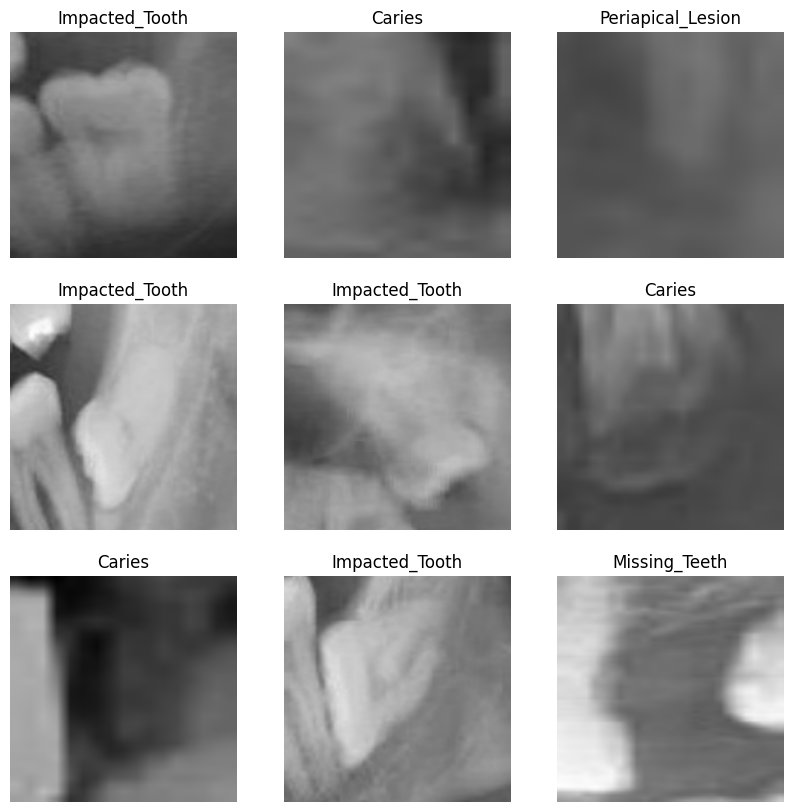

In [15]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.15)
])

In [17]:
labels = []

for _, y in train_dataset:
    labels.extend(y.numpy())

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(3.2421631530705772), 1: np.float64(0.95807150595883), 2: np.float64(0.35774462705436155), 3: np.float64(3.0258340461933275), 4: np.float64(1.915624153804495)}


In [18]:
base_model = EfficientNetB0(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = True

In [19]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=True)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

In [20]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 4,013,953 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    MODEL_PATH / "best_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [23]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.6813 - loss: 0.9729
Epoch 1: val_accuracy improved from None to 0.87510, saving model to /content/drive/MyDrive/dental-vision/models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dental-vision/models/best_model.keras
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 459s 375ms/step - accuracy: 0.7983 - loss: 0.6463 - val_accuracy: 0.8751 - val_loss: 0.3332 - learning_rate: 0.0010
Epoch 2/10
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9124 - loss: 0.3130
Epoch 2: val_accuracy improved from 0.87510 to 0.89656, saving model to /content/drive/MyDrive/dental-vision/models/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dental-vision/models/best_model.keras
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 409s 370ms/step - accuracy: 0.9225 - loss: 0.2827 - val_accuracy: 0.8966 - val_loss: 0.3034 - learning_rate: 0.0010
Epoch 3/10
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9

In [24]:
best_model = tf.keras.models.load_model(
    MODEL_PATH / "best_model.keras"
)

print("Best model loaded successfully.")

Best model loaded successfully.


In [25]:
test_loss, test_accuracy = best_model.evaluate(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

241/241 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.9803 - loss: 0.0728

Test Loss: 0.0728
Test Accuracy: 0.9803


In [26]:
import numpy as np

predictions = best_model.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)

241/241 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step


In [27]:
true_labels = np.concatenate([
    labels.numpy()
    for _, labels in test_dataset
])

In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4
    )
)

                   precision    recall  f1-score   support

        Bone_Loss     0.9536    0.9735    0.9634       528
           Caries     0.9638    0.9767    0.9702      1716
   Impacted_Tooth     0.9968    0.9888    0.9928      4116
    Missing_Teeth     0.9642    0.9764    0.9703       552
Periapical_Lesion     0.9605    0.9508    0.9556       792

         accuracy                         0.9803      7704
        macro avg     0.9678    0.9732    0.9705      7704
     weighted avg     0.9804    0.9803    0.9803      7704



In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

[[ 514    3    3    8    0]
 [   6 1676    4   10   20]
 [  17   20 4070    2    7]
 [   1    6    2  539    4]
 [   1   34    4    0  753]]


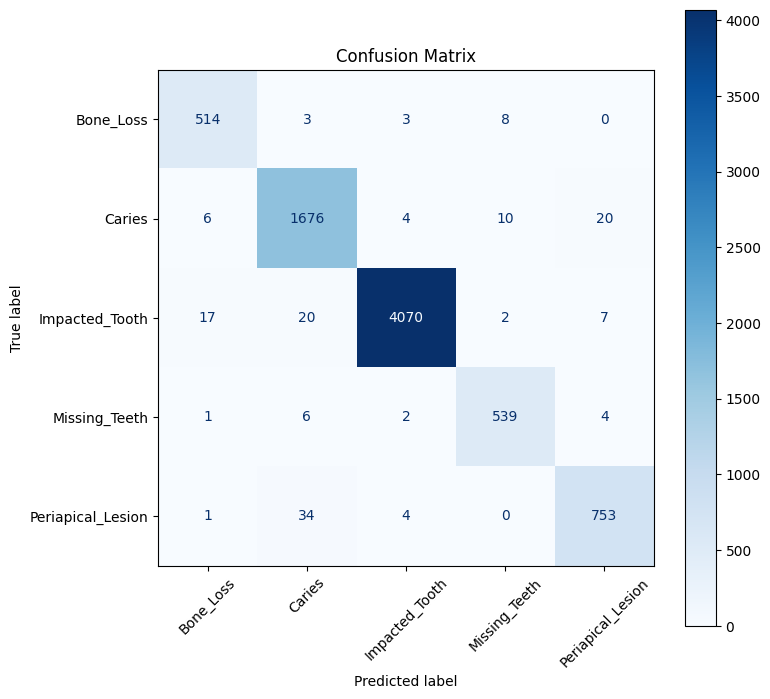

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

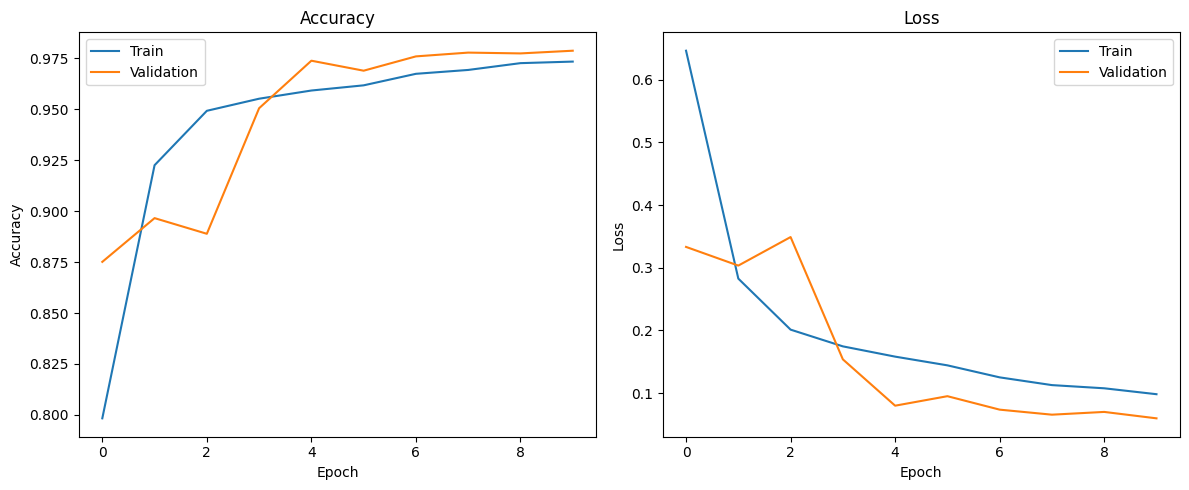

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.show()

In [32]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    MODEL_PATH / "training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [33]:
base_model.trainable = True

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:

checkpoint_finetune = ModelCheckpoint(
    MODEL_PATH / "fine_tuned_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [ ]:
history_finetune = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint_finetune,
        reduce_lr
    ]
)

Epoch 1/10
 518/1106 ━━━━━━━━━━━━━━━━━━━━ 3:28 355ms/step - accuracy: 0.9747 - loss: 0.0821

In [ ]:
best_model = tf.keras.models.load_model(
    MODEL_PATH / "fine_tuned_model.keras"
)

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["val_accuracy"], label="Baseline")
plt.plot(history_finetune.history["val_accuracy"], label="Fine-tuned")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["val_loss"], label="Baseline")
plt.plot(history_finetune.history["val_loss"], label="Fine-tuned")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

In [ ]:
best_model = tf.keras.models.load_model(
    MODEL_PATH / "fine_tuned_model.keras"
)

print("Fine-tuned model loaded successfully!")

In [ ]:
test_loss, test_accuracy = best_model.evaluate(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
predictions = best_model.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    digits=4
))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Fine-Tuned Model Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

accuracy = accuracy_score(true_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average="weighted"
)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(results)

results.to_csv(MODEL_PATH / "evaluation_results.csv", index=False)

print("\nEvaluation results saved successfully!")